**Hi,folks**
       Today we understand gradient descent in detail

gradient descent is an optimization algorithm that improves the parameters step by step to finally get the answer close to the definitive answer. In the beginning, the weights take an initial value. In each step, the amount of error decreases.

Gradient descent plays a key role in optimizing machine learning and deep learning models. This method is used not only independently but also as part of more complex algorithms, enabling the optimization of models through the minimization of the cost function. Due to its flexibility and power, gradient descent is applied in a wide range of applications, from image recognition to natural language processing.

**θ = θ - α * ∇J(θ)**
θ is the loss function
α is the learning rate
∇J(θ) is the gradient of the cost or loss function with respect to θ


**How does Gradient Descent work?**

The gradient descent algorithm’s purpose is to minimise a given function (say cost function). It executes two phases iteratively to attain this goal:

1. Calculate the function’s gradient (slope) and first order derivative at that point.
2. Make a step (move) in the opposite direction of the gradient, increasing the slope by alpha times the gradient at that point from the current position.

**Types**
1. Batch gradient descent
2. stochastic gradient descent
3. mini-batch gradient descent

**Process**
**step1:** **Intialization**
The model parameters are initialized with specified values or randomly.

**step2:**  **calculate gradient of loss or cost function**
For each parameter in the model, the partial derivative of the cost function with respect to that parameter is calculated

**new_param = old_param - (learning rate)*(gradient)**
The gradient represents the slope of the cost function at the current parameter point and indicates the direction in which, if moved, the cost function would increase.

**step3:**  **Update Parameters**
The model parameters are updated based on the calculated gradients and the learning rate (α). This update usually involves reducing the parameter values in the direction of the cost function gradient.

**step4:**  **Repeat until convergence**
The process of calculating gradients and updating parameters is repeated until a specific stopping condition is met (e.g., a certain number of iterations, minimal change in the cost function between two consecutive iterations, or the gradient nearing zero).

# code from scratch gradient descent

In [83]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

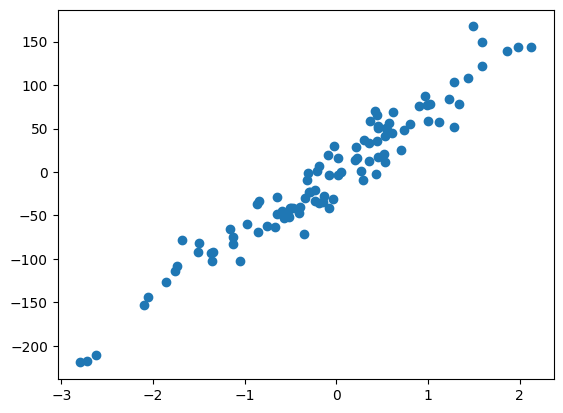

In [84]:
X,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20)
plt.scatter(X,y)

In [85]:
print(X.shape,y.shape)
print(X.ravel().shape,y.shape)

(100, 1) (100,)
(100,) (100,)


In [86]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X,y)
print(lr.coef_,lr.intercept_)

[72.88120536] 0.8068939958590295


In [87]:
class GDregressor:
    def __init__(self,learning_rate,epochs):
        self.learning_rate=learning_rate
        self.epochs=epochs
        self.m=47.04
        self.b=-120
    def fit(self,X,y):
        b_values=[]
        m_values=[]
        for i in range(self.epochs):
            loss_slope_b=-2*np.sum(y-self.m*X.ravel()-self.b)
            self.b=self.b-self.learning_rate*loss_slope_b
            loss_slope_m=-2*np.sum((y-self.m*X.ravel()-self.b)*X.ravel())
            self.m=self.m-self.learning_rate*loss_slope_m
            m_values.append(self.m)
            b_values.append(self.b)
            # print(self.b,sep="-")
        print(self.b,self.m)
        plt.plot(range(self.epochs),b_values)
        # plt.plot(range(self.epochs),m_values,color="red")
        plt.xlabel("Epochs/Iterations")
        plt.ylabel("b values")
        plt.title("convergence of b values in gradient descent")
        plt.show()

        plt.plot(range(self.epochs), m_values, color="red")
        plt.xlabel("Epochs/Iterations")
        plt.ylabel("m values")
        plt.title("Convergence of m values in Gradient Descent")
        plt.show()
    def predict(self,X):
        return self.m*X+self.b
    

0.8040009987868113 72.87956121706641


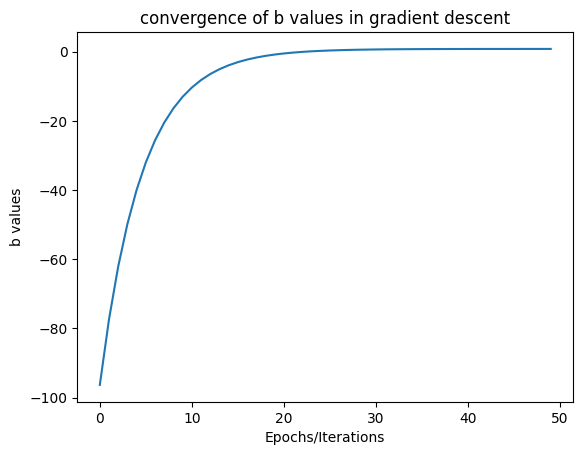

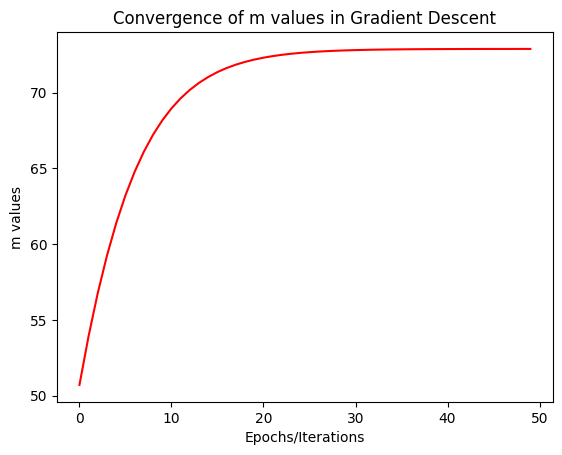

In [88]:
gd=GDregressor(learning_rate=0.001,epochs=50)
gd.fit(X,y)

**This graph show how's the value of b and m converges acc to epoches and learning rate**

# Now, move to Batch gradient descent

In [89]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [90]:
X,y=load_diabetes(return_X_y=True)
print(X.shape,y.shape)

(442, 10) (442,)


In [91]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [92]:
print(lr.coef_)
print(lr.intercept_)

[  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
151.34560453985995


In [93]:
y_pred=lr.predict(x_test)
print(r2_score(y_test,y_pred))

0.4526027629719195


In [94]:
x_train.shape

(353, 10)

In [95]:
class GDRegressor:
    def __init__(self,learning_rate=0.01,epochs=100):
        self.learning_rate=learning_rate
        self.epochs=epochs
        self.coeff_=None
        self.intercept_=None
    def fit(self,X,y):
        # initialize coff and intercept
        self.intercept_=0
        self.coeff_=np.ones(x_train.shape[1])
        # print(self.coeff_,self.intercept_)

        for i in range(self.epochs):
            y_hat=np.dot(x_train,self.coeff_)+self.intercept_
            
            intercept_der=-2*np.mean(y-y_hat)
            self.intercept_=self.intercept_-(self.learning_rate*intercept_der)

            coeff_der=-2*np.dot((y-y_hat),x_train)/x_train.shape[0]
            self.coeff_=self.coeff_-(self.learning_rate*coeff_der)

        print(self.coeff_,self.intercept_)
    def predict(self,X):
        return np.dot(x_test,self.coeff_)+self.intercept_

In [96]:
gdr=GDRegressor(learning_rate=0.5,epochs=1000)
gdr.fit(x_train,y_train)

[  41.82977756 -203.23644652  509.6557063   325.07401153  -71.07194191
 -119.33187737 -215.85264692  144.71021659  376.52729984  111.97619094] 151.372591059285


In [97]:
y_pred=gdr.predict(x_test)
print(r2_score(y_test,y_pred))

0.4588776166235029


# stochastic gradient descent

**problem with batch gradient descent**
on large data we have to do a lot of computation,to do enough computation we not have proper hardware

Stochastic Gradient Descent (SGD) is a faster, more memory‑efficient version of gradient descent. Instead of using the whole dataset to calculate the gradient at each step, it updates the model parameters using just one randomly chosen data point. This makes the updates noisy and less smooth, but the randomness helps the algorithm escape local minima and often reach good solutions more quickly. Over many iterations, the parameters gradually stabilize, which is why SGD is widely used in training large machine learning models and deep neural networks.

In [100]:
class SGDRegressor:
    def __init__(self,learning_rate=0.01,epochs=100):
        self.learning_rate=learning_rate
        self.epochs=epochs
        self.coeff_=None
        self.intercept_=None
    def fit(self,X,y):
        # initialize coff and intercept
        self.intercept_=0
        self.coeff_=np.ones(x_train.shape[1])
        # print(self.coeff_,self.intercept_)

        for i in range(self.epochs):
            for j in range(x_train.shape[0]):
                idx=np.random.randint(0,x_train.shape[0])
                y_hat=np.dot(x_train[idx],self.coeff_)+self.intercept_

                intercept_der=-2*(y[idx]-y_hat)
                self.intercept_=self.intercept_-(self.learning_rate*intercept_der)

                coeff_der=-2*(y[idx]-y_hat)*x_train[idx]
                self.coeff_=self.coeff_-(self.learning_rate*coeff_der)
        print(self.coeff_,self.intercept_)

            
        # print(self.coeff_,self.intercept_)
    def predict(self,X):
        return np.dot(x_test,self.coeff_)+self.intercept_

In [101]:
sgd=SGDRegressor(learning_rate=0.5,epochs=50)
sgd.fit(x_train,y_train)

[  91.18095432 -139.20452912  506.38129348  278.67942533 -378.14513278
    7.92096351  -33.64377527  265.75813313  511.51794081   69.60127754] 152.92700233794253


In [103]:
y_pred=sgd.predict(x_test)
print(r2_score(y_test,y_pred))

0.44323939331717843


In [ ]:
from sklearn.linear_model import SGDRegressor
reg=SGDRegressor(max_iter=200,learning_rate="constant",eta0=0.01)
reg.fit(x_train,y_train)
y_pred=reg.predict(x_test)
print(r2_score(y_test,y_pred))

0.45174633807762943


we clearly see that here we require less no of epochs

# Mini-Batch gradent descent
Mini‑batch gradient descent is a middle ground between batch gradient descent and stochastic gradient descent. Instead of using the entire dataset (batch) or just one sample (stochastic) to update the model parameters, it processes small groups of samples called mini‑batches, typically 32, 64, or 128 data points at a time. This approach balances efficiency and stability: it reduces the noise of single‑sample updates while still being faster and more memory‑friendly than full batch updates. That’s why mini‑batch gradient descent is the most common choice in training deep learning models.

In [109]:
lr.fit(x_train,y_train)
print(lr.coef_,lr.intercept_)
y_pred=lr.predict(x_test)
print(r2_score(y_test,y_pred))

[  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743] 151.34560453985995
0.4526027629719195


In [127]:
class MBGDRegressor:
    def __init__(self,learning_rate=0.01,epochs=100,batch_size=32):
        self.learning_rate=learning_rate
        self.epochs=epochs
        self.batch_size=batch_size
        self.coeff_=None
        self.intercept_=None
    def fit(self,x_train,y_train):
        # initialize coff and intercept
        self.intercept_=0
        self.coeff_=np.ones(x_train.shape[1])
        # print(self.coeff_,self.intercept_)

        for i in range(self.epochs):
            for j in range(int(x_train.shape[0]/self.batch_size)):
                idx = np.random.choice(x_train.shape[0], int(self.batch_size), replace=False)


                y_hat=np.dot(x_train[idx],self.coeff_)+self.intercept_
                
                intercept_der=-2*np.mean(y_train[idx]-y_hat)
                self.intercept_=self.intercept_-(self.learning_rate*intercept_der)

                coeff_der=-2*np.dot((y_train[idx]-y_hat),x_train[idx])/x_train.shape[0]
                self.coeff_=self.coeff_-(self.learning_rate*coeff_der)

        print(self.coeff_,self.intercept_)
    def predict(self,x_test):
        return np.dot(x_test,self.coeff_)+self.intercept_

In [139]:
mbr=MBGDRegressor(learning_rate=0.5,epochs=250,batch_size=x_train.shape[0]/10)
mbr.fit(x_train,y_train)
y_pred=mbr.predict(x_test)
print(r2_score(y_test,y_pred))

[  56.29710139  -56.60952474  307.55790973  216.34151824   18.86689132
  -10.92247184 -160.44477413  143.44172286  248.01843114  142.02003511] 140.1462437322124
0.4036391031300095
